# ReAct Agent with Structured Weather Output

This notebook keeps the same weather-agent setup, but adds LangChain structured output
using `ToolStrategy(...)` so the final result is a typed Pydantic object.


## Why `ToolStrategy`

For custom chat-model adapters like `ChatClaudeAgSDK`, `ToolStrategy(...)` is the most explicit
and reliable way to request structured output inside `create_agent(...)`.


In [1]:
from __future__ import annotations

from pydantic import BaseModel, Field
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy
from langchain_core.tools import tool

from langchain_claude_agent import ChatClaudeAgSDK, check_claude_agent_sdk_credentials

ok, message = check_claude_agent_sdk_credentials()
print(f"Credentials OK: {ok}")
print(message)
if not ok:
    raise RuntimeError("Claude Agent SDK credentials are not configured.")


Credentials OK: True
claude_agent_sdk: probe completed successfully


In [2]:
class WeatherReport(BaseModel):
    """Structured weather answer returned by the agent."""

    city: str = Field(description="Normalized city name")
    forecast: str = Field(description="Weather summary")
    alerts: list[str] = Field(description="Important weather alerts")
    confidence: str = Field(description="Confidence label for the answer")


WEATHER_FIXTURES = {
    "asuncion": {
        "forecast": "Sunny, 31 C",
        "alerts": ["High UV index after 11:00.", "Light breeze from the south."],
    },
    "london": {
        "forecast": "Cloudy, 11 C",
        "alerts": ["Patchy rain in the afternoon.", "Low visibility near the river."],
    },
}


@tool
def get_weather(city: str) -> str:
    """Return a deterministic weather summary for a city."""
    fixture = WEATHER_FIXTURES.get(city.lower())
    if fixture is None:
        return f"No forecast configured for {city}."
    return fixture["forecast"]


@tool
def get_weather_alerts(city: str) -> str:
    """Return deterministic weather alerts for a city."""
    fixture = WEATHER_FIXTURES.get(city.lower())
    if fixture is None:
        return f"No alerts configured for {city}."
    return "; ".join(fixture["alerts"])


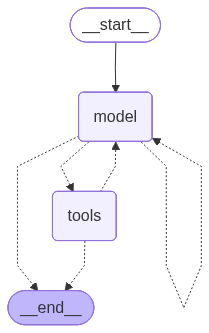

In [3]:
structured_agent = create_agent(
    model=ChatClaudeAgSDK(model="sonnet"),
    tools=[get_weather, get_weather_alerts],
    system_prompt="You are a precise weather assistant. Always use tools before answering.",
    response_format=ToolStrategy(WeatherReport),
)
structured_agent


In [4]:
result = structured_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "What is the weather in London? Return structured weather data.",
            }
        ]
    }
)

report = result["structured_response"]
report


WeatherReport(city='London', forecast='Cloudy, 11°C (52°F)', alerts=[], confidence='High - Data retrieved from current weather service')

In [5]:
print(type(report))
print(report.model_dump())


<class '__main__.WeatherReport'>
{'city': 'London', 'forecast': 'Cloudy, 11°C (52°F)', 'alerts': [], 'confidence': 'High - Data retrieved from current weather service'}


In [6]:
for idx, message in enumerate(result["messages"], start=1):
    print(f"[{idx}] {type(message).__name__}")
    print(message.content)
    print("-" * 80)


[1] HumanMessage
What is the weather in London? Return structured weather data.
--------------------------------------------------------------------------------
[2] AIMessage
I'll check the weather in London for you.
--------------------------------------------------------------------------------
[3] ToolMessage
Cloudy, 11 C
--------------------------------------------------------------------------------
[4] AIMessage

--------------------------------------------------------------------------------
[5] ToolMessage
Returning structured response: city='London' forecast='Cloudy, 11°C (52°F)' alerts=[] confidence='High - Data retrieved from current weather service'
--------------------------------------------------------------------------------
